# 214. Shortest Palindrome
https://leetcode.com/problems/shortest-palindrome/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| KMP / failure function | $O(n)$ | $O(n)$ | Optimal — find longest palindrome prefix |
| Rolling hash (Rabin-Karp) | $O(n)$ | $O(1)$ | Hash collision risk |
| Brute force | $O(n^2)$ | $O(n)$ | Check each prefix |

## Methodology

We need to find the longest palindromic prefix of `s`, then prepend the reverse of the remaining suffix. Using the KMP failure function: construct `s + '#' + reverse(s)`, compute the failure array, and the last value tells us the length of the longest palindromic prefix. We then prepend the reverse of the suffix after that prefix.

## Solutions

### C#

In [ ]:
public class Solution {
    public string ShortestPalindrome(string s) {
        string rev = new string(s.Reverse().ToArray());
        string combined = s + "#" + rev;
        int[] fail = new int[combined.Length];
        for (int i = 1; i < combined.Length; i++) {
            int j = fail[i - 1];
            while (j > 0 && combined[i] != combined[j])
                j = fail[j - 1];
            if (combined[i] == combined[j])
                j++;
            fail[i] = j;
        }
        int palLen = fail[combined.Length - 1];
        return rev.Substring(0, s.Length - palLen) + s;
    }
}

### Python

In [ ]:
class Solution:
    def shortestPalindrome(self, s: str) -> str:
        rev = s[::-1]
        combined = s + '#' + rev
        fail = [0] * len(combined)
        for i in range(1, len(combined)):
            j = fail[i - 1]
            while j > 0 and combined[i] != combined[j]:
                j = fail[j - 1]
            if combined[i] == combined[j]:
                j += 1
            fail[i] = j
        pal_len = fail[-1]
        return rev[:len(s) - pal_len] + s

### Go

In [ ]:
func shortestPalindrome(s string) string {
    rev := reverse(s)
    combined := s + "#" + rev
    fail := make([]int, len(combined))
    for i := 1; i < len(combined); i++ {
        j := fail[i-1]
        for j > 0 && combined[i] != combined[j] {
            j = fail[j-1]
        }
        if combined[i] == combined[j] {
            j++
        }
        fail[i] = j
    }
    palLen := fail[len(combined)-1]
    return rev[:len(s)-palLen] + s
}

func reverse(s string) string {
    runes := []rune(s)
    for i, j := 0, len(runes)-1; i < j; i, j = i+1, j-1 {
        runes[i], runes[j] = runes[j], runes[i]
    }
    return string(runes)
}

### Rust

In [ ]:
impl Solution {
    pub fn shortest_palindrome(s: String) -> String {
        let rev: String = s.chars().rev().collect();
        let combined = format!("{}#{}", s, rev);
        let bytes = combined.as_bytes();
        let mut fail = vec![0usize; bytes.len()];
        for i in 1..bytes.len() {
            let mut j = fail[i - 1];
            while j > 0 && bytes[i] != bytes[j] {
                j = fail[j - 1];
            }
            if bytes[i] == bytes[j] {
                j += 1;
            }
            fail[i] = j;
        }
        let pal_len = fail[bytes.len() - 1];
        format!("{}{}", &rev[..s.len() - pal_len], s)
    }
}

## Example Scenarios

### 1. Common Case — Most of String Already Palindromic
**Input:** `s = "aacecaaa"`

Build combined = "aacecaaa#aaacecaa". KMP failure array's last value is 7, meaning the longest palindromic prefix has length 7: "aacecaa". Remaining suffix is "a" (1 char). Prepend its reverse to get "aaacecaaa".

WHY it's tricky: It isn't — 7 of 8 characters form a palindromic prefix, requiring only 1 prepended character.

$|s| = 8,\ \text{palindromic prefix} = 7,\ \text{prepend} = 8 - 7 = 1 \text{ char. Result length} = 9$

### 2. Slightly Complex — Only First Character is Palindromic Prefix
**Input:** `s = "abcd"`

Combined = "abcd#dcba". Failure array ends at 1, meaning only "a" is a palindromic prefix. Must prepend reverse of "bcd" = "dcb". Result: "dcbabcd". The result nearly doubles the input length.

WHY it's tricky: All distinct characters means the palindromic prefix is minimal (just the first char). The prepended portion is nearly the entire reversed string.

$|s| = 4,\ \text{pal prefix} = 1,\ \text{prepend} = 3. \text{ Result length} = 7 \approx 2n - 1$

### 3. Edge Case: Time Factor — 50K Same Characters
**Input:** `s = "aaa...a"` (50,000 'a's)

The entire string is a palindrome (prefix length = 50,000). Combined string has length 100,001. The failure function climbs linearly, resets at '#', then climbs back. Nothing needs to be prepended.

WHY it's tricky: The failure function for "aaa...a#aaa...a" has non-trivial backtracking at '#'. Each char in the second half may cause multiple while-loop iterations. Amortized time remains $O(n)$ because each backtrack reduces j.

$\text{Combined length} = 2n + 1 = 100{,}001. \text{ KMP: } O(2n+1) = O(n)$

### 4. Edge Case: Space Factor — 50K Distinct Characters
**Input:** `s = "abcde..." (50,000 chars cycling a-z)`

Palindromic prefix is just the first character. Prepend = 49,999 chars. Result = 99,999 chars ≈ 2n. The combined string for KMP uses O(2n) space for the failure array.

WHY it's tricky: Result is nearly 2× the input. The failure array uses O(2n) integers. Peak memory is about 3× the input for combined string + failure array + result.

$\text{Space: } O(2n+1) \text{ combined} + O(2n+1) \text{ fail array} + O(2n-1) \text{ result} \approx O(n)$

### 5. Almost-Impossible — Adversarial Repeating Pattern
**Input:** `s = "ababab...ababc"` (49,999 'ab' repetitions + 'c', total 50,000 chars)

Palindromic prefix is just "a" (length 1). The KMP failure function exercises maximum backtracking: the repeating "ab" creates a long failure chain (fail[i] = i-2 for even positions). When the reverse portion mismatches, KMP backtracks through the entire chain.

WHY it's tricky: The trailing 'c' breaks the pattern, making palindromic prefix minimal. Backtracking steps are heavy but amortized $O(n)$ holds. Constant factors are high.

$\text{Pal prefix} = 1. \text{ Prepend} = 49{,}999. \text{ Result} = 99{,}999. \text{ KMP backtracking: amortized } O(n)$


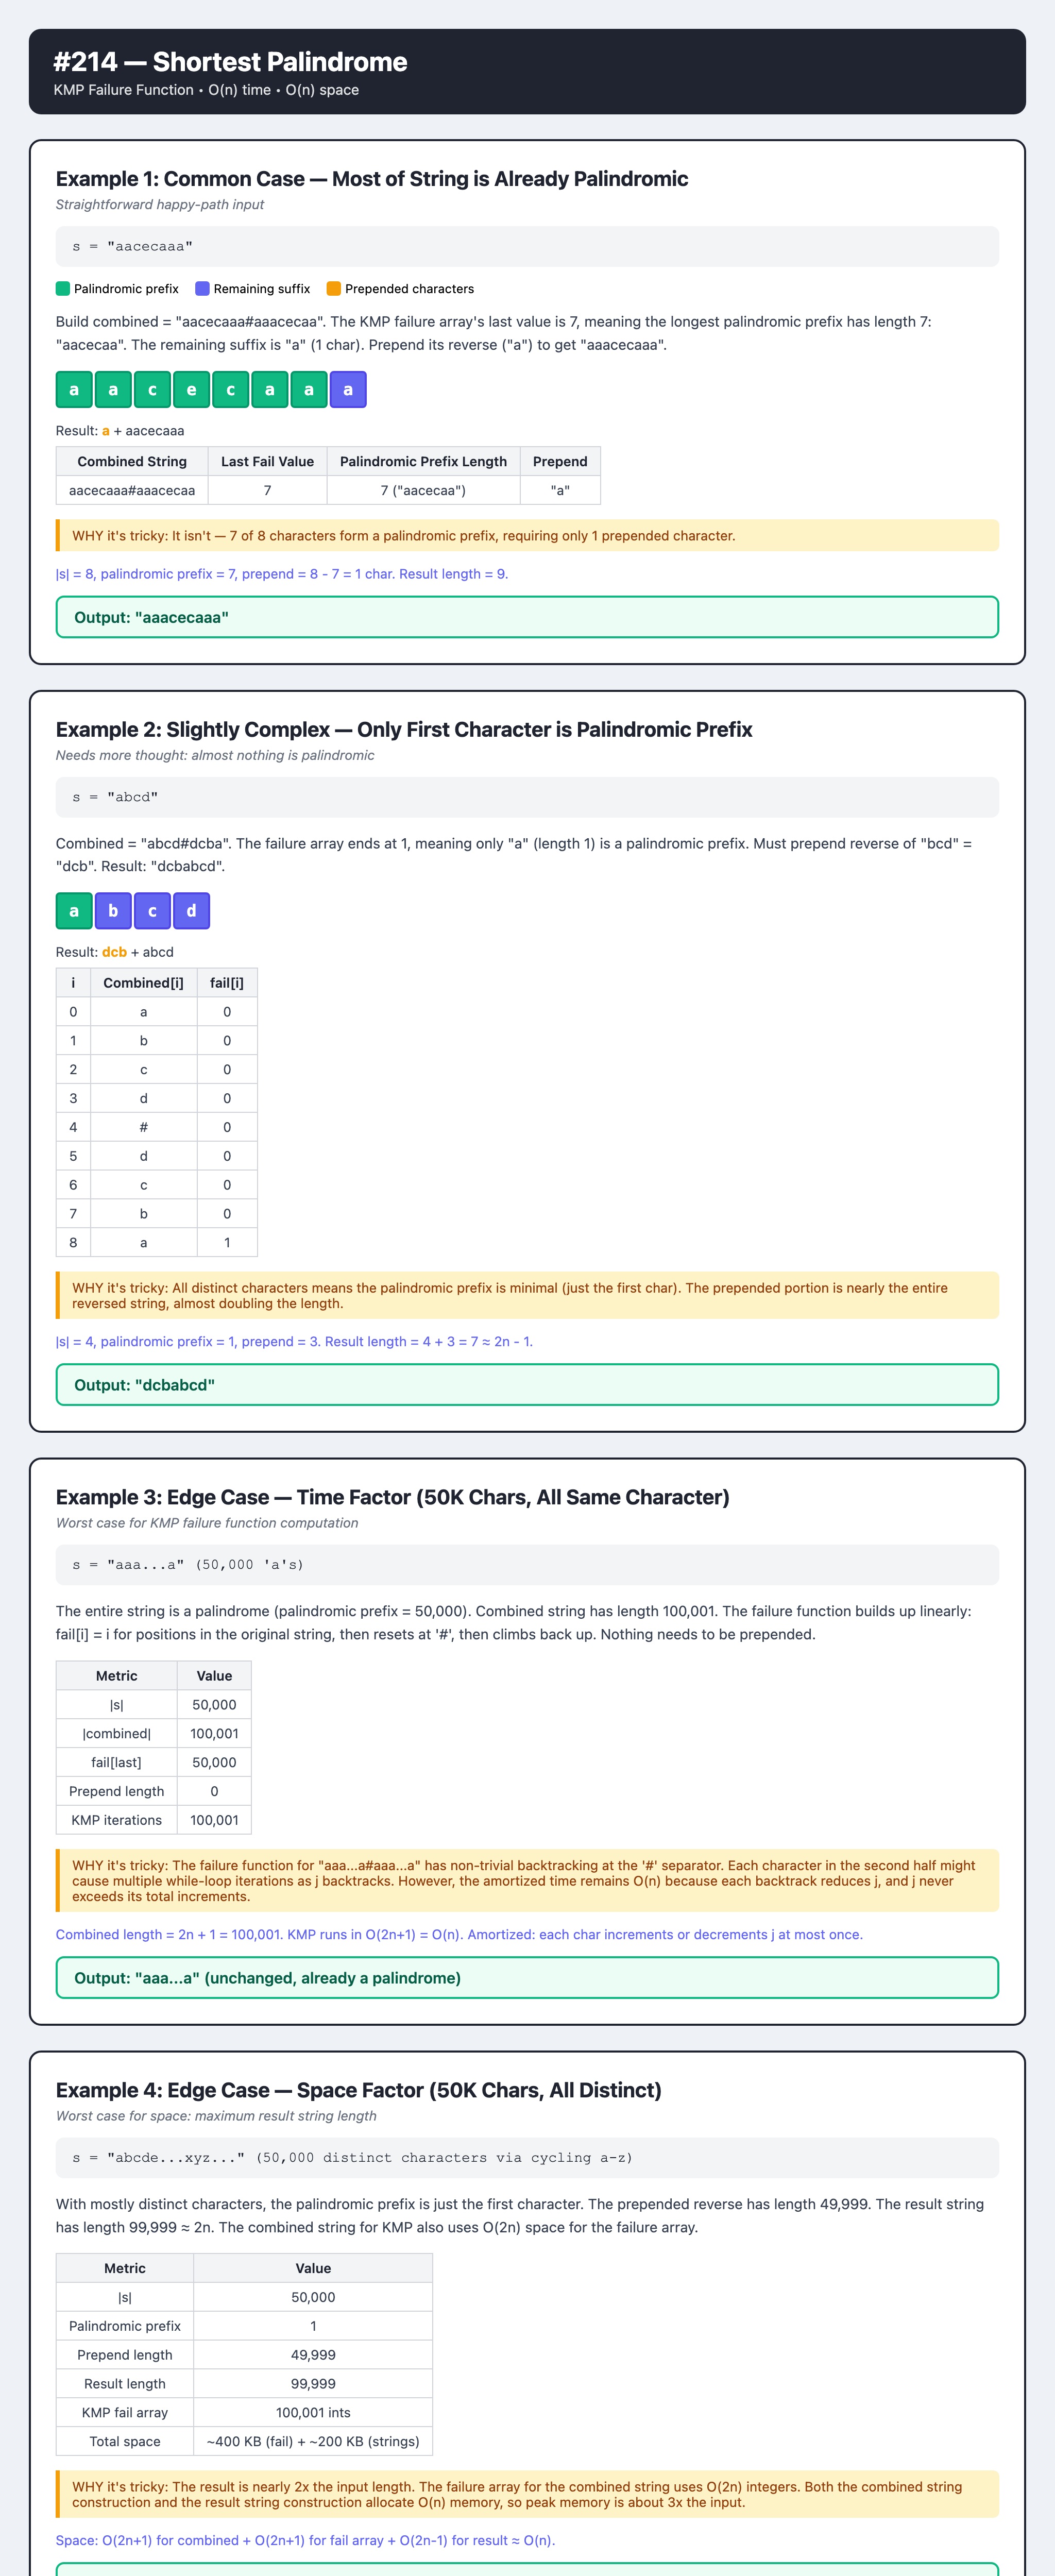